In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import glob
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def build_medical_model():
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)


    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)

    model = model.to(DEVICE)
    model.eval()
    return model, weights

model, weights = build_medical_model()
target_layer = model.layer4[-1].conv3

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 126MB/s]


In [2]:
class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.layer = layer
        self.activations = None
        self.gradients = None
        self.fwd_hook = self.layer.register_forward_hook(self._save_act)
        self.bwd_hook = self.layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, input, output): self.activations = output.detach()
    def _save_grad(self, module, grad_in, grad_out): self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().numpy()

    def remove(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

In [3]:
def generate_saliency(model, input_tensor, class_idx):
    input_tensor.requires_grad_()
    output = model(input_tensor)
    score = output[0, class_idx]
    score.backward()

    saliency, _ = torch.max(input_tensor.grad.data.abs(), dim=1)
    saliency = saliency.squeeze().cpu().numpy()

    saliency -= saliency.min()
    saliency /= (saliency.max() + 1e-8)
    return saliency

In [5]:
def process_medical_image(img_url):
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_img = Image.open(img_url).convert("RGB")

    input_tensor = transform(raw_img).unsqueeze(0).to(DEVICE)

    output = model(input_tensor)
    pred_idx = torch.argmax(output, dim=1).item()
    labels = ["Normal", "Pneumonia"]

    gcam_engine = GradCAM(model, target_layer)
    heatmap = gcam_engine.generate(input_tensor, pred_idx)
    gcam_engine.remove()

    saliency = generate_saliency(model, input_tensor, pred_idx)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(raw_img.resize((224,224)))
    ax[0].set_title(f"Prediction: {labels[pred_idx]}")
    ax[0].axis('off')

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    ax[1].imshow(raw_img.resize((224,224)))
    ax[1].imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax[1].set_title("Grad-CAM (Regional Importance)")
    ax[1].axis('off')

    ax[2].imshow(saliency, cmap='hot')
    ax[2].set_title("Saliency Map (Pixel Sensitivity)")
    ax[2].axis('off')

    plt.show()



Found 120 image files.

--- Processing image: /content/1.jpg (1/5) ---


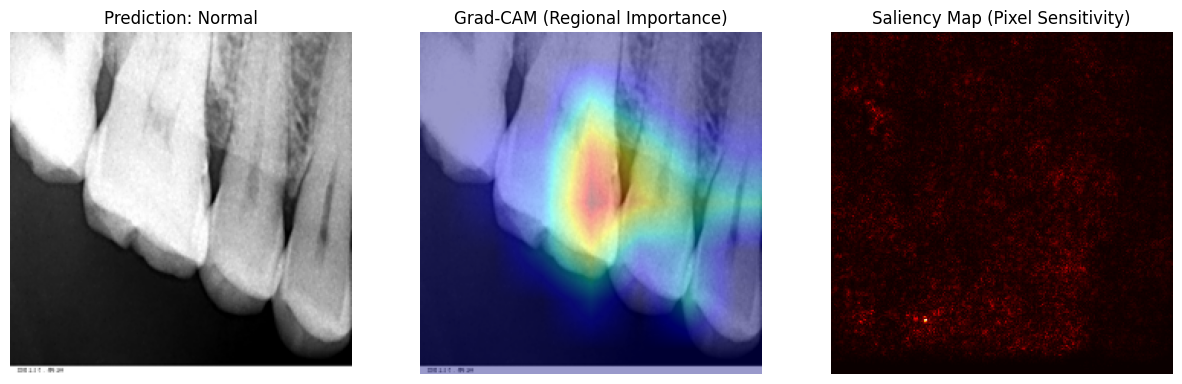


--- Processing image: /content/2.jpg (2/5) ---


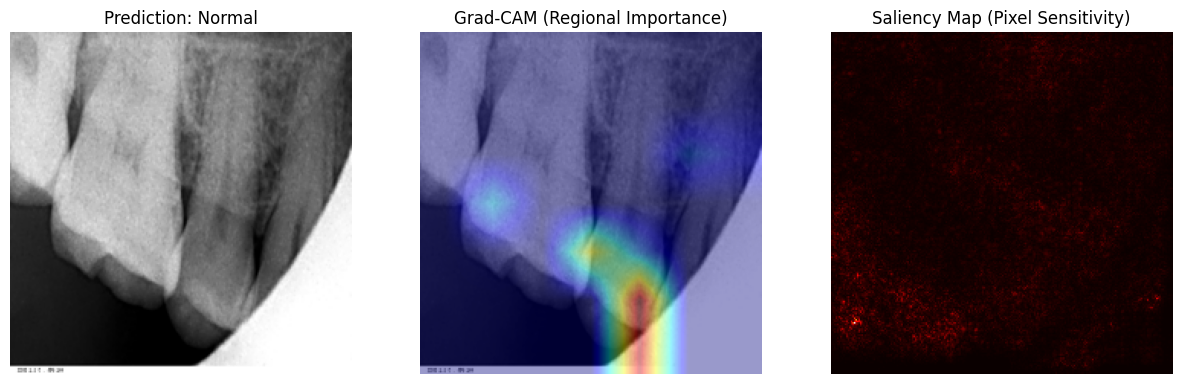


--- Processing image: /content/3.jpg (3/5) ---


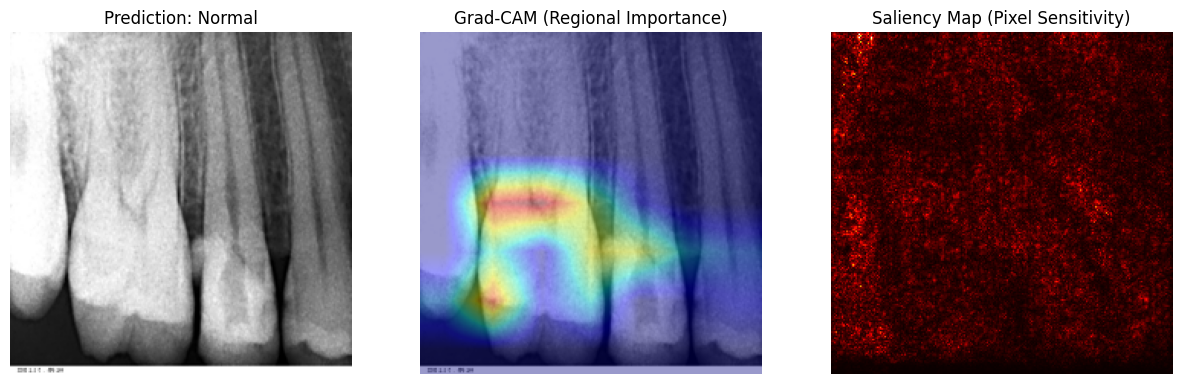


--- Processing image: /content/4.jpg (4/5) ---


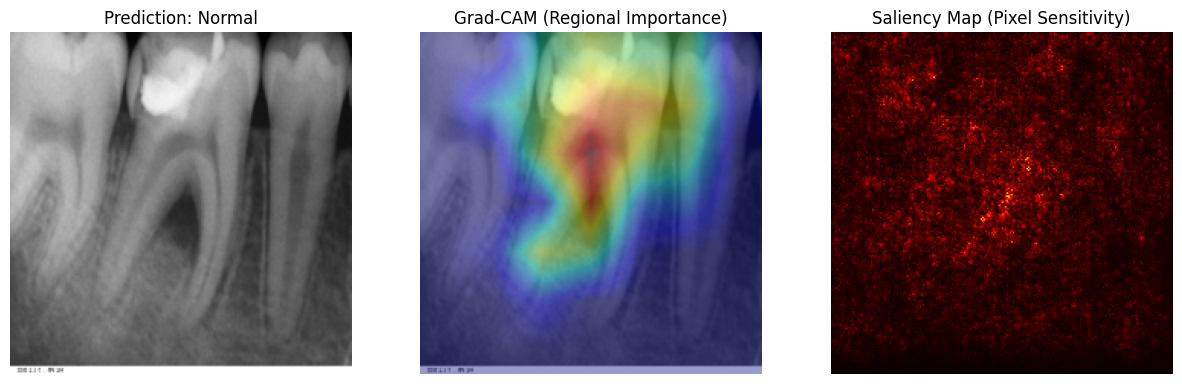


--- Processing image: /content/5.jpg (5/5) ---


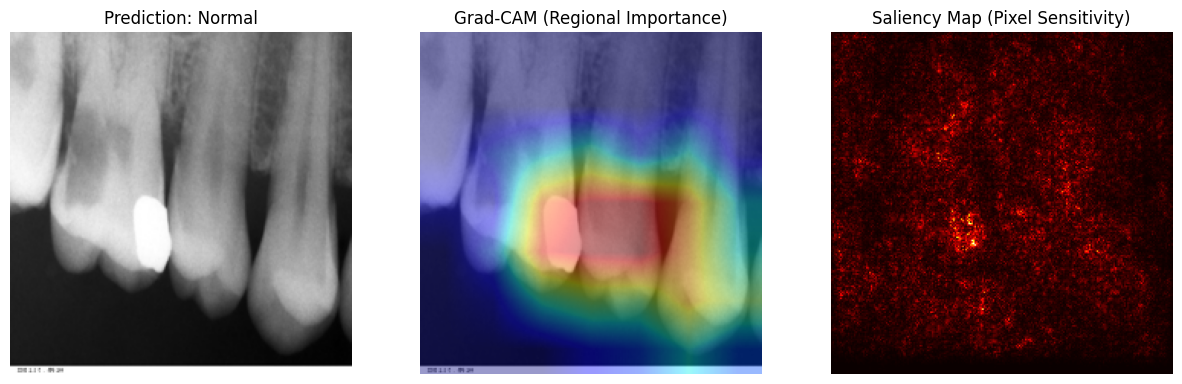

In [8]:
image_files = sorted(glob.glob('/Dataset/*.jpg'), key=lambda x: int(x.split('/')[-1].split('.')[0])) #Medical Image Dataset Dental Images of kjbjl from kaggle

print(f"Found {len(image_files)} image files.")
num_images_to_process = 5

for i, img_path in enumerate(image_files[:num_images_to_process]):
    print(f"\n--- Processing image: {img_path} ({i+1}/{num_images_to_process}) ---")
    process_medical_image(img_path)